In [16]:
import os
from pathlib import Path
import warnings

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
import seaborn as sns
from IPython.display import display, Markdown

import sim_ranking as sr
import ml_tools as mlt

warnings.simplefilter(action='ignore', category=FutureWarning)

In [17]:
results_dir = Path("/Users/claudy/dev/work/data/sim_ranking/results/gnn/simple/1125_1146_cv_test")
wdata = Path("/Users/claudy/dev/work/data")

In [18]:
run_config = sr.ml.gnn_gm.RunConfig.from_yaml(results_dir / "run_config.yaml")

In [19]:
# Load observed data to get metadata
nzgmdb_ffp = wdata / run_config.rel_obs_data_ffp
obs_data = sr.data.load_obs_nzgmdb(nzgmdb_ffp)

In [20]:
# Distance matrix
dist_matrix = sr.utils.calculate_distance_matrix(obs_data.sites, obs_data.site_df)

In [21]:
# Load attention coefficients
val_attn_coefs = pd.read_parquet(results_dir / "val_attn_coeffs.parquet")

In [22]:
# Add site-to-site distance
row_ind = dist_matrix.index.get_indexer_for(val_attn_coefs.site_int)
col_ind = dist_matrix.columns.get_indexer_for(val_attn_coefs.obs_site)
val_attn_coefs["dist"] = dist_matrix.values[row_ind, col_ind]

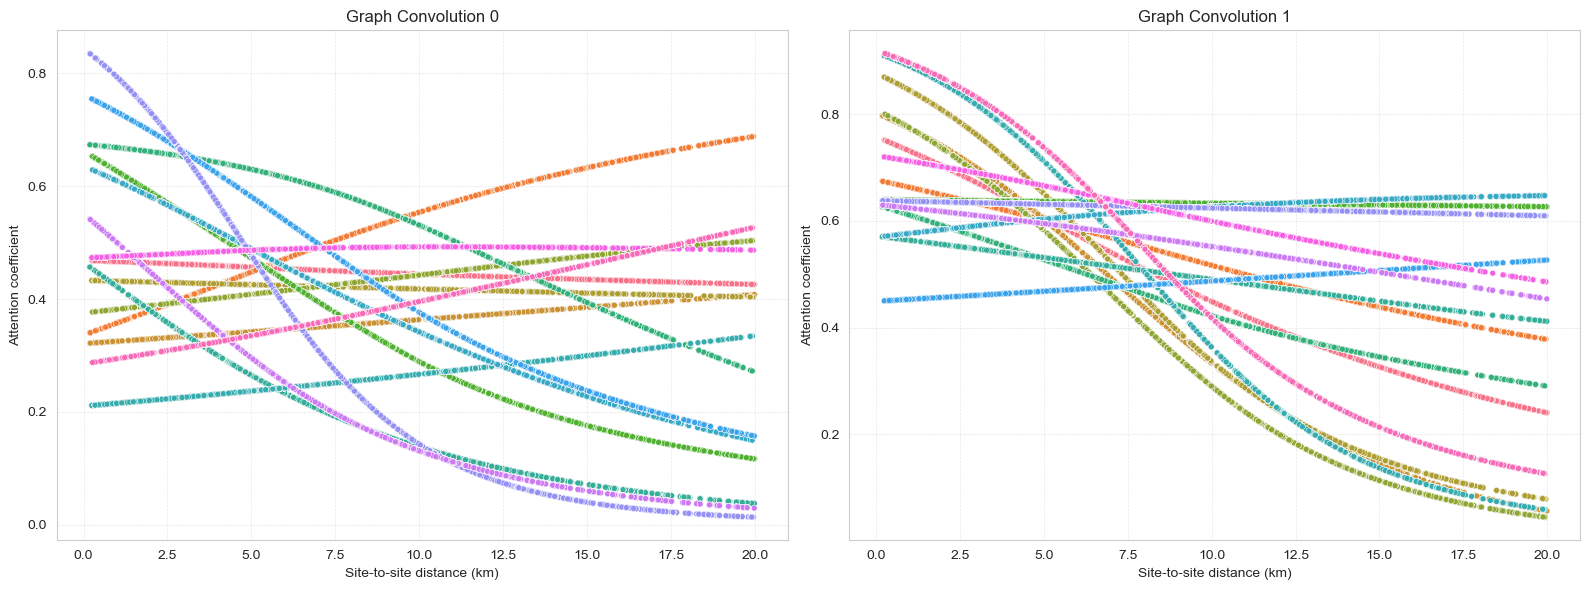

In [23]:
fig, (ax1, ax2) = mlt.plotting.get_fig_axes(2, 2, 1, (8, 6))

sns.scatterplot(data=val_attn_coefs, x="dist", y="conv_0", ax=ax1, hue="cv_iter", legend=False, size=1.0)
ax1.set_xlabel("Site-to-site distance (km)")
ax1.set_ylabel("Attention coefficient")
ax1.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax1.set_title("Graph Convolution 0")

sns.scatterplot(data=val_attn_coefs, x="dist", y="conv_1", ax=ax2, hue="cv_iter", legend=False, size=1.0)
ax2.set_xlabel("Site-to-site distance (km)")
ax2.set_ylabel("Attention coefficient")
ax2.grid(linewidth=0.5, alpha=0.5, linestyle="--")
ax2.set_title("Graph Convolution 1")

fig.tight_layout()

In [24]:
val_attn_coefs.cv_iter.unique()

array(['cv_0', 'cv_1', 'cv_2', 'cv_3', 'cv_4', 'cv_5', 'cv_6', 'cv_7',
       'cv_8', 'cv_9', 'cv_10', 'cv_11', 'cv_12', 'cv_13', 'cv_14'],
      dtype=object)

In [25]:
val_attn_coefs.loc[val_attn_coefs.cv_iter == "cv_0"].sort_index()

,conv_0,conv_1,event,obs_site,site_int,cv_iter,dist
1905903_PHFS_ARKS,0.460374,0.655177,1905903,ARKS,PHFS,cv_0,3.513235
1905903_PHFS_INSS,0.462797,0.685580,1905903,INSS,PHFS,cv_0,2.541496
1905903_PHFS_RQGS,0.441343,0.410057,1905903,RQGS,PHFS,cv_0,11.419972
1905903_PHFS_UHCS,0.429195,0.269365,1905903,UHCS,PHFS,cv_0,18.076801
1974827_PHFS_ARKS,0.460374,0.655177,1974827,ARKS,PHFS,cv_0,3.513235
...,...,...,...,...,...,...,...
3717543_GODS_MQZ,0.431095,0.288123,3717543,MQZ,GODS,cv_0,16.987810
3717543_GODS_PARS,0.464339,0.704944,3717543,PARS,GODS,cv_0,1.897990
3792018_SHFC_DFHS,0.439067,0.380567,3792018,DFHS,SHFC,cv_0,12.586473
3792018_SHFC_KOWC,0.433077,0.309153,3792018,KOWC,SHFC,cv_0,15.860623


In [26]:
val_attn_coefs.loc[val_attn_coefs.cv_iter == "cv_1"].sort_index()

,conv_0,conv_1,event,obs_site,site_int,cv_iter,dist
1905903_UHCS_ARKS,0.635042,0.436039,1905903,ARKS,UHCS,cv_1,15.180981
1905903_UHCS_INSS,0.639807,0.431029,1905903,INSS,UHCS,cv_1,15.552416
1905903_UHCS_KIRS,0.654997,0.414801,1905903,KIRS,UHCS,cv_1,16.805836
1905903_UHCS_PHFS,0.669107,0.399353,1905903,PHFS,UHCS,cv_1,18.076801
1974827_UHCS_ARKS,0.635042,0.436039,1974827,ARKS,UHCS,cv_1,15.180981
...,...,...,...,...,...,...,...
3721796_HVSC_RHSC,0.599241,0.472584,3721796,RHSC,HVSC,cv_1,12.666415
3721796_HVSC_SHLC,0.536305,0.532515,3721796,SHLC,HVSC,cv_1,9.082302
3792018_OXZ_DFHS,0.678100,0.389304,3792018,DFHS,OXZ,cv_1,18.948416
3792018_OXZ_KOWC,0.630892,0.440374,3792018,KOWC,OXZ,cv_1,14.865208


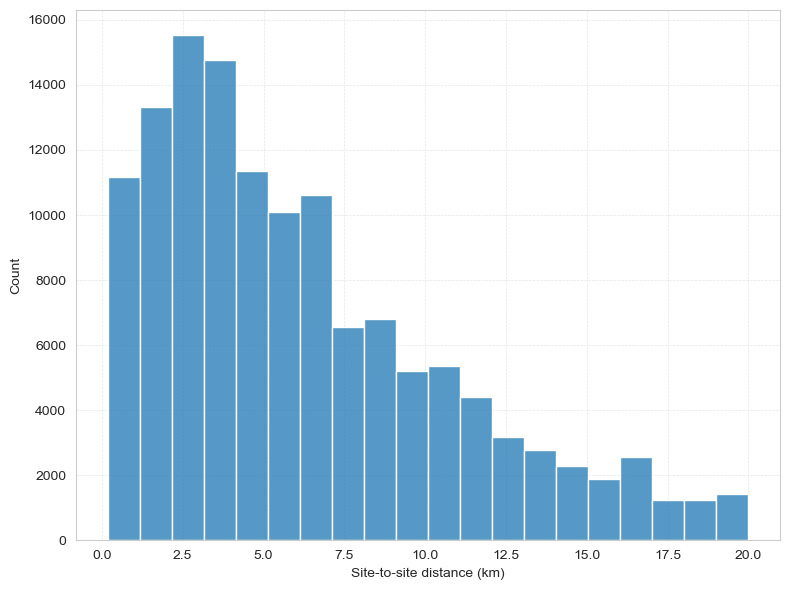

In [27]:
## Site-to-site distance distribution
fig, ax = plt.subplots(figsize=(8, 6))

sns.histplot(val_attn_coefs["dist"], bins=20, ax=ax)

ax.set_xlabel("Site-to-site distance (km)")
ax.set_ylabel("Count")
ax.grid(linewidth=0.5, alpha=0.5, linestyle="--")

fig.tight_layout()
